<a href="https://colab.research.google.com/github/srinitha27/web-traffic-analysis/blob/main/webtrafficanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the traffic data
df = pd.read_csv('/content/traffic.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


## User Flow Visualization

To visualize the user flow, we will first extract the sequence of pages (tracks) visited within each session. Then, we will identify the transitions between these pages and represent them as a flow.

In [8]:
# Extract page sequences for each session
# Filter for 'pageview' events to focus on page navigation
session_page_sequences = (
    df[df['event'] == 'pageview']
    .groupby('session_id')['track']
    .apply(list)
    .reset_index()
)

display(session_page_sequences.head())


,session_id,track
0,1,[Spending Addiction]
1,2,[Spending Addiction]
2,3,"[P*$$Y Fairy (OTW), P*$$Y Fairy (OTW)]"
3,4,[Can't Get Enough]
4,5,[كملت نص دينى]


Next, we'll process these sequences to count the transitions between pages. This will form the 'source', 'target', and 'value' data needed for a Sankey diagram.

In [9]:
from collections import defaultdict

# Initialize a dictionary to store transitions
transitions = defaultdict(lambda: defaultdict(int))

# Iterate through each session's page sequence to count transitions
for index, row in session_page_sequences.iterrows():
    session_tracks = row['track']
    if len(session_tracks) > 1:
        for i in range(len(session_tracks) - 1):
            source = session_tracks[i]
            target = session_tracks[i+1]
            transitions[source][target] += 1

# Convert the transitions dictionary into a pandas DataFrame suitable for Sankey
sankey_data = []
for source, targets in transitions.items():
    for target, value in targets.items():
        sankey_data.append({'source': source, 'target': target, 'value': value})

sankey_df = pd.DataFrame(sankey_data)

display(sankey_df.head())


,source,target,value
0,P*$$Y Fairy (OTW),P*$$Y Fairy (OTW),1
1,Been Solid,Been Solid,2
2,dear katara,dear katara,29
3,Primero Yo,Primero Yo,1
4,Beautiful Soul,Beautiful Soul,33


Now that we have the transition data, we can create a Sankey diagram using `plotly` to visualize the user flow. This diagram will show how users navigate from one track (page) to another.

## Implementing Millisecond Timestamps in Pandas

To capture granular timestamps, you can use `pd.to_datetime` and ensure your data includes milliseconds. Here's an example using a sample DataFrame:

In [11]:
import pandas as pd

# Create a sample DataFrame with string timestamps including milliseconds
data = {
    'event_id': [1, 2, 3],
    'timestamp_str': [
        '2023-10-27 10:00:00.123',
        '2023-10-27 10:00:01.456',
        '2023-10-27 10:00:02.789'
    ]
}
df_time = pd.DataFrame(data)

# Convert the string column to datetime objects with millisecond precision
df_time['timestamp'] = pd.to_datetime(df_time['timestamp_str'])

# Display the DataFrame and check the data type
display(df_time)
print(f"Data type of 'timestamp' column: {df_time['timestamp'].dtype}")

# You can also extract components, including milliseconds
df_time['milliseconds'] = df_time['timestamp'].dt.microsecond // 1000
display(df_time)


,event_id,timestamp_str,timestamp
0,1,2023-10-27 10:00:00.123,2023-10-27 10:00:00.123
1,2,2023-10-27 10:00:01.456,2023-10-27 10:00:01.456
2,3,2023-10-27 10:00:02.789,2023-10-27 10:00:02.789


Data type of 'timestamp' column: datetime64[ns]


,event_id,timestamp_str,timestamp,milliseconds
0,1,2023-10-27 10:00:00.123,2023-10-27 10:00:00.123,123
1,2,2023-10-27 10:00:01.456,2023-10-27 10:00:01.456,456
2,3,2023-10-27 10:00:02.789,2023-10-27 10:00:02.789,789


## Average Time Spent on Each Track

To calculate the average time spent on each track, we'll determine the duration a user spent on a particular track before moving to the next event within the same session. As discussed, the precision of our `df['date']` column might limit the accuracy of these durations.

First, we ensure the data is sorted by `session_id` and `date` to correctly calculate the time differences between consecutive events within a session. We'll focus on 'pageview' events for this analysis.

In [14]:
# Sort the DataFrame to ensure correct sequence for time difference calculation
df_sorted = df.sort_values(by=['session_id', 'date']).copy()

# Filter for pageview events as 'time on track' is usually related to viewing
# Use .copy() to avoid SettingWithCopyWarning
pageviews_for_duration = df_sorted[df_sorted['event'] == 'pageview'].copy()

# Calculate the time spent on the current track (time until the next event in the same session)
# We shift the date column and subtract the current date to get the duration.
# The last event in a session will have a NaN, which we can fill or drop.
pageviews_for_duration['time_on_track'] = pageviews_for_duration.groupby('session_id')['date'].diff(periods=-1).abs()

# Display the first few rows to show the calculated 'time_on_track'
display(pageviews_for_duration.head())


,event,date,country,city,artist,album,track,isrc,linkid,time_diff,new_session,session_id,time_on_track
199012,pageview,2021-08-19,United States,Wetumpka,Gunna,Drip Season 3 (Deluxe),Spending Addiction,Unknown,00073307-ae96-5089-a117-4783afb42f8e,NaT,True,1,NaT
154114,pageview,2021-08-20,United States,Queens,Gunna,Drip Season 3 (Deluxe),Spending Addiction,Unknown,00073307-ae96-5089-a117-4783afb42f8e,1 days,True,2,NaT
152893,pageview,2021-08-19,United States,San Antonio,Jhené Aiko,Chilombo,P*$$Y Fairy (OTW),Unknown,00126b32-0c35-507b-981c-02c80d2aa8e7,0 days,False,3,0 days
158978,pageview,2021-08-19,United States,Valrico,Jhené Aiko,Chilombo,P*$$Y Fairy (OTW),Unknown,00126b32-0c35-507b-981c-02c80d2aa8e7,0 days,False,3,NaT
205014,pageview,2021-08-19,United States,Orlando,K CAMP,RARE Sound,Can't Get Enough,Unknown,0018cfff-50a1-5984-9715-01ef2d11a49a,NaT,True,4,NaT


Now, we can calculate the average time spent on each unique track. We will also handle any `NaT` values (Not a Time) which might arise for the last event in a session.

In [15]:
# Calculate the average time spent on each track
# Drop NaT values before calculating the mean, as they represent the end of a session
average_time_per_track = pageviews_for_duration.dropna(subset=['time_on_track']) \
                                              .groupby('track')['time_on_track'].mean() \
                                              .sort_values(ascending=False)

# Convert timedelta to seconds for better readability if desired, or keep as Timedelta
# For display, we'll keep it as Timedelta to show the full granularity (even if 0s)

print("\nAverage Time Spent on Each Track:")
display(average_time_per_track.head(10))



Average Time Spent on Each Track:


,time_on_track
track,
#BrooklynBloodPop!,0 days
Raptors,0 days
Ramen OJ,0 days
Raised Up,0 days
Rain On Your Skin (feat. Mooski),0 days
Racks On (feat. YoungBoy Never Broke Again),0 days
RR ANTHEM [Explicit],0 days
"ROLLIN N CONTROLLIN, Pt.2 (PICTURE ME)",0 days
ROLLIN N CONTROLLIN FREESTYLE,0 days


In [10]:
import plotly.graph_objects as go

# Prepare data for Sankey diagram
# Get all unique nodes (source and target tracks)
all_nodes = list(pd.unique(sankey_df[['source', 'target']].values.ravel('K')))

# Create a mapping from node name to node index
node_to_index = {node: i for i, node in enumerate(all_nodes)}

# Map source and target names to their respective indices
sankey_df['source_index'] = sankey_df['source'].map(node_to_index)
sankey_df['target_index'] = sankey_df['target'].map(node_to_index)

# Create the Sankey diagram
fig = go.Figure(
    data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color='black', width=0.5),
            label=all_nodes, # Labels for the nodes
        ),
        link=dict(
            source=sankey_df['source_index'],
            target=sankey_df['target_index'],
            value=sankey_df['value'],
        )
    )]
)

fig.update_layout(title_text='User Flow: Track Transitions', font_size=10)
fig.show()


In [2]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    226278 non-null  object
 1   date     226278 non-null  object
 2   country  226267 non-null  object
 3   city     226267 non-null  object
 4   artist   226241 non-null  object
 5   album    226273 non-null  object
 6   track    226273 non-null  object
 7   isrc     219157 non-null  object
 8   linkid   226278 non-null  object
dtypes: object(9)
memory usage: 15.5+ MB
None
event         0
date          0
country      11
city         11
artist       37
album         5
track         5
isrc       7121
linkid        0
dtype: int64


In [3]:
# Convert 'date' column to datetime
df['date'] = pd.to_datetime(df['date'])

# Fill missing values with 'Unknown'
for col in ['country', 'city', 'artist', 'album', 'track', 'isrc']:
    df[col] = df[col].fillna('Unknown')

# Display updated info and null counts
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   event    226278 non-null  object        
 1   date     226278 non-null  datetime64[ns]
 2   country  226278 non-null  object        
 3   city     226278 non-null  object        
 4   artist   226278 non-null  object        
 5   album    226278 non-null  object        
 6   track    226278 non-null  object        
 7   isrc     226278 non-null  object        
 8   linkid   226278 non-null  object        
dtypes: datetime64[ns](1), object(8)
memory usage: 15.5+ MB
None
event      0
date       0
country    0
city       0
artist     0
album      0
track      0
isrc       0
linkid     0
dtype: int64


In [4]:
# Sort data by linkid and date to correctly identify sessions
df = df.sort_values(by=['linkid', 'date'])

# Calculate the time difference between consecutive events for each user
df['time_diff'] = df.groupby('linkid')['date'].diff()

# Define a session timeout (e.g., 30 minutes)
session_timeout = pd.Timedelta(minutes=30)

# Identify new sessions: a new session starts if the time difference is greater than the timeout
df['new_session'] = (df['time_diff'] > session_timeout) | (df['time_diff'].isnull())

# Assign a unique session ID for each new session
df['session_id'] = df['new_session'].cumsum()

# Display the first few rows with session IDs and time differences
display(df.head())

,event,date,country,city,artist,album,track,isrc,linkid,time_diff,new_session,session_id
199012,pageview,2021-08-19,United States,Wetumpka,Gunna,Drip Season 3 (Deluxe),Spending Addiction,Unknown,00073307-ae96-5089-a117-4783afb42f8e,NaT,True,1
154114,pageview,2021-08-20,United States,Queens,Gunna,Drip Season 3 (Deluxe),Spending Addiction,Unknown,00073307-ae96-5089-a117-4783afb42f8e,1 days,True,2
1248,click,2021-08-19,United States,Valrico,Jhené Aiko,Chilombo,P*$$Y Fairy (OTW),Unknown,00126b32-0c35-507b-981c-02c80d2aa8e7,NaT,True,3
21084,click,2021-08-19,United States,San Antonio,Jhené Aiko,Chilombo,P*$$Y Fairy (OTW),Unknown,00126b32-0c35-507b-981c-02c80d2aa8e7,0 days,False,3
152893,pageview,2021-08-19,United States,San Antonio,Jhené Aiko,Chilombo,P*$$Y Fairy (OTW),Unknown,00126b32-0c35-507b-981c-02c80d2aa8e7,0 days,False,3


In [5]:
# Compute total sessions
total_sessions = df['session_id'].nunique()

# Compute total users
total_users = df['linkid'].nunique()

# Compute session duration
session_duration = df.groupby('session_id')['date'].apply(lambda x: x.max() - x.min())

# Calculate bounce rate
# A bounce session is defined as a session with only one event
session_event_counts = df.groupby('session_id').size()
bounce_sessions = session_event_counts[session_event_counts == 1].count()
bounce_rate = (bounce_sessions / total_sessions) * 100

# Calculate average session duration
average_session_duration = session_duration.mean()

print(f"Total Sessions: {total_sessions}")
print(f"Total Users: {total_users}")
print(f"Bounce Rate: {bounce_rate:.2f}%")
print(f"Average Session Duration: {average_session_duration}")

Total Sessions: 6563
Total Users: 3839
Bounce Rate: 27.41%
Average Session Duration: 0 days 00:00:00


/tmp/ipykernel_682/2176690900.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Views', y='Track', data=top_10_tracks, palette='viridis')


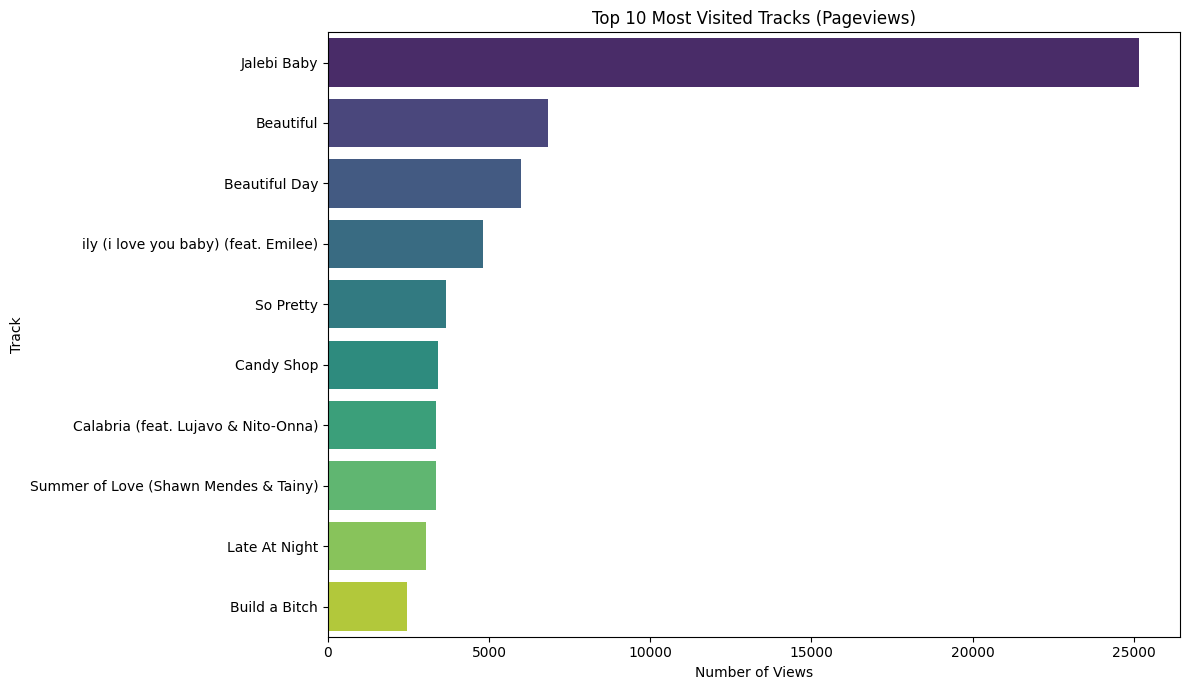

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for 'pageview' events
pageviews_df = df[df['event'] == 'pageview']

# Get the top 10 most visited tracks
top_10_tracks = pageviews_df['track'].value_counts().nlargest(10).reset_index()
top_10_tracks.columns = ['Track', 'Views']

# Create a bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Views', y='Track', data=top_10_tracks, palette='viridis')
plt.title('Top 10 Most Visited Tracks (Pageviews)')
plt.xlabel('Number of Views')
plt.ylabel('Track')
plt.tight_layout()
plt.show()

/tmp/ipykernel_682/2569052628.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Exit_Count', y='Track', data=top_10_exit_pages, palette='magma')


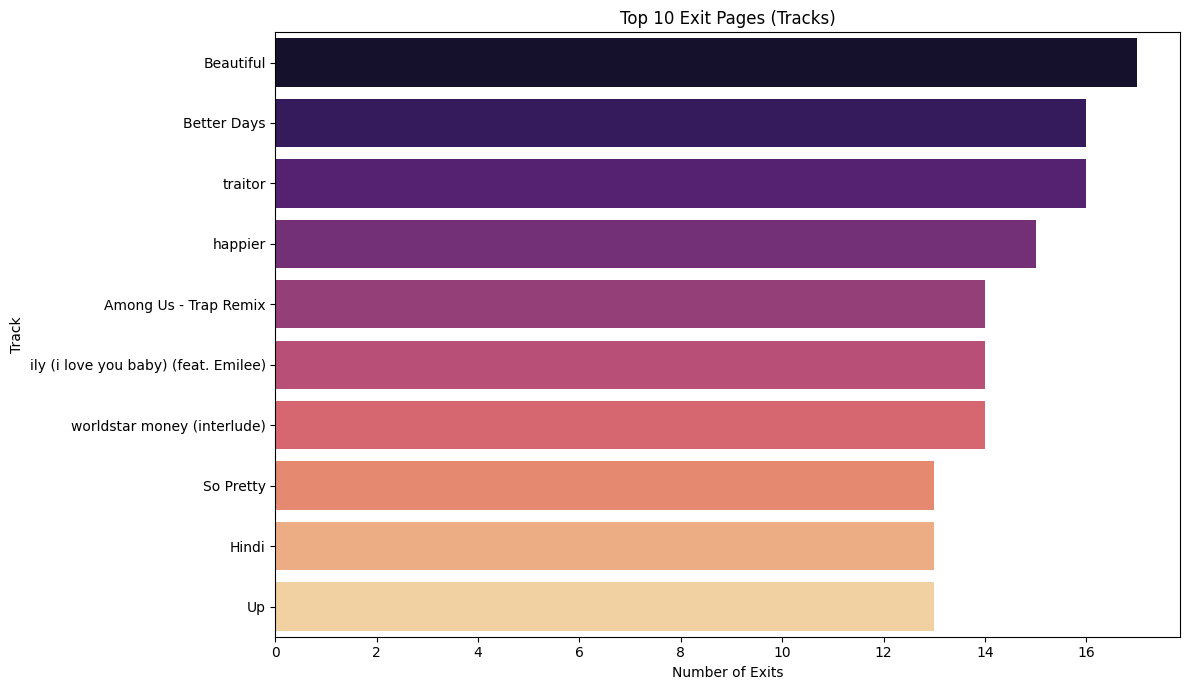

In [7]:
# Get the last event for each session to identify the exit page
exit_pages_df = df.groupby('session_id').last().reset_index()

# Count the occurrences of each track as an exit page
top_10_exit_pages = exit_pages_df['track'].value_counts().nlargest(10).reset_index()
top_10_exit_pages.columns = ['Track', 'Exit_Count']

# Create a bar chart for top 10 exit pages
plt.figure(figsize=(12, 7))
sns.barplot(x='Exit_Count', y='Track', data=top_10_exit_pages, palette='magma')
plt.title('Top 10 Exit Pages (Tracks)')
plt.xlabel('Number of Exits')
plt.ylabel('Track')
plt.tight_layout()
plt.show()